# Расчет параметров эффективности математической модели

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.special import gammainc
from scipy.stats import gamma as gamma_dist


from config import MathModelInput, load_config
import executor
import replicaset
import helpers

from render_typst import FormulaRenderer, get_typst_context

TYPST_PATH: Path = Path("../diploma/math-stuff.typ")
TYPST_RENDERER: FormulaRenderer = FormulaRenderer()
TYPST_CONTEXT: str = get_typst_context(TYPST_PATH)


def output(t: str):
    TYPST_RENDERER.render(TYPST_CONTEXT + t)

Здесь нужно задать конфиг, по которому будут рассчитаны параметры эффективности

In [2]:
CONFIG_PATH = "configs/example.yaml"

In [3]:
MATH_MODEL_INPUT: MathModelInput = load_config(CONFIG_PATH)

print(f"Загруженные настройки: {MATH_MODEL_INPUT}")

Загруженные настройки: intensity_search_LSI=1000.0 intensity_update_LSI=1000.0 intensity_search_GSI=1000.0 intensity_update_GSI=1000.0 replicaset_count=5 cluster_time_k=1.5 cluster_time_theta=2.0 cluster_net_speed=4096.0 user_time_k=1.5 user_time_theta=2.0 user_net_speed=1024.0 row_size=128 data_cardinality=1000 fk_cardinality=100 cpu_frequency=1000000.0 mem_frequency=1000000.0 wal_time=0.002 timeout=2.0 btree_order=3


## Алгоритмы для ЛВИ

### Поиск в ЛВИ

Рассчитаем максимальное количество запросов, которое может выдержать СУБД

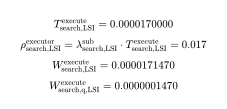

In [4]:
data_cardinality_per_replicaset = replicaset.data_cardinality_per_replicaset(
    MATH_MODEL_INPUT.data_cardinality, MATH_MODEL_INPUT.replicaset_count
)
pk_per_fk_per_cardinality_per_replicaset = (
    replicaset.pk_per_fk_per_cardinality_per_replicaset(
        data_cardinality_per_replicaset, MATH_MODEL_INPUT.fk_cardinality
    )
)

time_execute_search_LSI = executor.time_execute_search_LSI(
    data_cardinality_per_replicaset,
    MATH_MODEL_INPUT.btree_order,
    pk_per_fk_per_cardinality_per_replicaset,
    MATH_MODEL_INPUT.cpu_frequency,
    MATH_MODEL_INPUT.mem_frequency,
)

subintensity_search_LSI = MATH_MODEL_INPUT.intensity_search_LSI
load_executor_search_LSI = executor.load(
    subintensity_search_LSI, time_execute_search_LSI
)

queue_length_execute_search_LSI = (
    executor.pollaczek_khinchin_deterministic_queue_length(
        subintensity_search_LSI, time_execute_search_LSI
    )
)
service_time_execute_search_LSI = executor.littles_law_deterministic(
    queue_length_execute_search_LSI, subintensity_search_LSI
)
queue_time_execute_search_LSI = executor.queue_time_deterministic(
    service_time_execute_search_LSI, time_execute_search_LSI
)

res = rf"""
$#time_execute_search_LSI = "{time_execute_search_LSI:.10f}"$

$#load_executor_search_LSI = #subintensity_search_LSI dot #time_execute_search_LSI = {load_executor_search_LSI}$

$#service_time_execute_search_LSI = {service_time_execute_search_LSI:.10f}$

$#queue_time_execute_search_LSI = {queue_time_execute_search_LSI:.10f}$
"""
output(res)

Расчет времени работы координатора

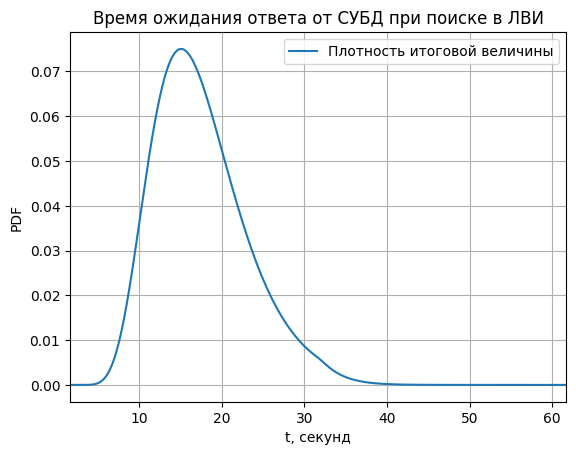

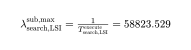

In [5]:
exec_plan_size = replicaset.exec_plan_size(MATH_MODEL_INPUT.row_size)
query_size = replicaset.query_size(MATH_MODEL_INPUT.row_size)

deterministic_part_of_tcsi_search_LSI = (
    exec_plan_size
    + MATH_MODEL_INPUT.row_size * pk_per_fk_per_cardinality_per_replicaset
) / MATH_MODEL_INPUT.cluster_net_speed


cluster_time_theta, cluster_time_k = (
    MATH_MODEL_INPUT.cluster_time_theta,
    MATH_MODEL_INPUT.cluster_time_k,
)
user_time_theta, user_time_k = (
    MATH_MODEL_INPUT.user_time_theta,
    MATH_MODEL_INPUT.user_time_k,
)

# общая сетка для СВ
x_grid = np.linspace(0, 30, 3000)

time_cluster_request_response_i_pdf = gamma_dist.pdf(
    x_grid, scale=cluster_time_theta * 2, a=cluster_time_k
)
time_cluster_request_response_i_cdf = gamma_dist.cdf(
    x_grid, scale=cluster_time_theta * 2, a=cluster_time_k
)
rv_i = helpers.RV(
    x_grid, time_cluster_request_response_i_pdf, time_cluster_request_response_i_cdf
).shift(deterministic_part_of_tcsi_search_LSI)

rv_max = helpers.RV.maximum(rv_i, rv_i)
for i in range(MATH_MODEL_INPUT.replicaset_count - 1):
    rv_max = helpers.RV.maximum(rv_i, rv_max)

# добавляем гамма-распределение задержки координатора
time_user_request_response_pdf = gamma_dist.pdf(
    x_grid, a=user_time_k, scale=user_time_theta
)
time_user_request_response_cdf = gamma_dist.cdf(
    x_grid, a=user_time_k, scale=user_time_theta
)
rv_extra = helpers.RV(
    x_grid, time_user_request_response_pdf, time_user_request_response_cdf
)

deterministic_part_of_tus_new = (
    query_size
    + MATH_MODEL_INPUT.row_size
    * pk_per_fk_per_cardinality_per_replicaset
    * MATH_MODEL_INPUT.replicaset_count
) / MATH_MODEL_INPUT.user_net_speed

time_user_search_LSI = (rv_max + rv_extra).shift(deterministic_part_of_tus_new)

# рисуем
plt.plot(
    time_user_search_LSI.x,
    time_user_search_LSI.pdf,
    label="Плотность итоговой величины",
)
plt.xlabel("t, секунд")
plt.ylabel("PDF")
plt.title("Время ожидания ответа от СУБД при поиске в ЛВИ")
plt.grid(True)
plt.legend()
plt.xlim(time_user_search_LSI.x[0], time_user_search_LSI.x[-1])
plt.show()

max_load_executor_search_LSI = 1 / time_execute_search_LSI

res = rf"""
$#max_subintensity_search_LSI = 1 / #time_execute_search_LSI = {max_load_executor_search_LSI:.3f}$
"""
output(res)

Проведем расчет вероятности необслуживания заявки при попадании в СУБД

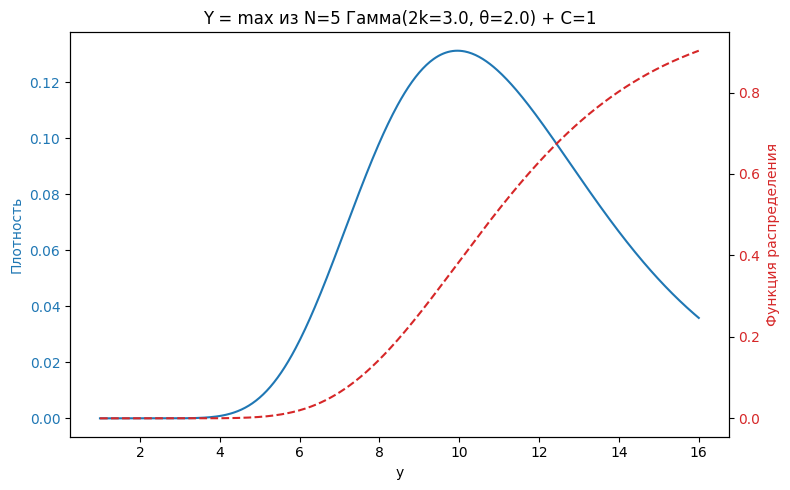

In [6]:
def cdf_Y(y, shape, theta, N, C):
    y = np.asarray(y, dtype=float)
    t = (y - C) / theta
    res = np.zeros_like(y)
    mask = y >= C
    res[mask] = gammainc(shape, t[mask]) ** N
    return res


def pdf_Y(y, shape, theta, N, C):
    y = np.asarray(y, dtype=float)
    t = (y - C) / theta
    res = np.zeros_like(y)
    mask = y >= C
    if not np.any(mask):
        return res
    t_m = t[mask]
    gamma_pdf = gamma_dist.pdf(y[mask] - C, a=shape, scale=theta)
    gamma_cdf = gammainc(shape, t_m)
    res[mask] = N * gamma_cdf ** (N - 1) * gamma_pdf
    return res


shape = MATH_MODEL_INPUT.cluster_time_k * 2
theta = MATH_MODEL_INPUT.cluster_time_theta
N = MATH_MODEL_INPUT.replicaset_count
C = 1


# Сетка для графика
y_vals = np.linspace(C, C + 15, 500)
pdf_vals = pdf_Y(y_vals, shape, theta, N, C)
cdf_vals = cdf_Y(y_vals, shape, theta, N, C)

# График с двумя осями
fig, ax1 = plt.subplots(figsize=(8, 5))
color1 = "tab:blue"
ax1.plot(y_vals, pdf_vals, color=color1, label="PDF f_Y(y)")
ax1.set_xlabel("y")
ax1.set_ylabel("Плотность", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)

ax2 = ax1.twinx()
color2 = "tab:red"
ax2.plot(y_vals, cdf_vals, color=color2, linestyle="--", label="CDF F_Y(y)")
ax2.set_ylabel("Функция распределения", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)

plt.title(f"Y = max из N={N} Гамма(2k={shape}, θ={theta}) + C={C}")
fig.tight_layout()
plt.show()
